In [62]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
import cv2
import time 
import os
#torch, torch vision, cv2

In [63]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device==torch.device('cpu'):
    print(':(')
else: 
    print(':)')

:(


In [64]:
#resizing to 224 since resnet takes 224*224*3 images
data_transforms={'train':transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val':transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
#cv2 alternative
def alt_transform(img):
    #resize
    img=cv2.resize(img,(256,256))
    
    #random resized crop
    crop_size=224
    upper_left=torch.randint(0,256-crop_size,size=(2))
    img=img[upper_left[0]:upper_left[0]+crop_size,
            upper_left[1]:upper_left[1]+crop_size]
    
    #random horizontal flip
    flip=torch.rand(1)>0.5
    if flip:
        img=img[:,::-1]
    img=torch.tensor(img.copy())
    return img


In [65]:
#need: datasets and dataloaders, here we split into 
#train set and validation set with ratio 4:1
data_dir = 'data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

In [66]:
dataset_sizes,class_names

({'train': 901, 'val': 224}, ['Cloudy', 'Rain', 'Shine', 'Sunrise'])

In [67]:
dataloaders,image_datasets

({'train': <torch.utils.data.dataloader.DataLoader at 0x19ba6e44d10>,
  'val': <torch.utils.data.dataloader.DataLoader at 0x19ba16d1190>},
 {'train': Dataset ImageFolder
      Number of datapoints: 901
      Root location: data\train
      StandardTransform
  Transform: Compose(
                 Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
                 RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
                 RandomHorizontalFlip(p=0.5)
                 ToTensor()
                 Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
             ),
  'val': Dataset ImageFolder
      Number of datapoints: 224
      Root location: data\val
      StandardTransform
  Transform: Compose(
                 Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
                 CenterCrop(size=(224, 224))
                 ToTensor()
                 Normalize(m

In [68]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#we only train the final fc layer so freeze model weights
for param in model.parameters():
    param.requires_grad = False

In [69]:
# Replace the fc layer to output 4 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names)) 
model = model.to(device) #sadly still cpu

In [70]:
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.fc.parameters(),lr=0.001980)

In [71]:
# For visualization purpose
training_results = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

In [73]:
import tqdm
num_epochs = 15
min_acc=1
for epoch in tqdm.tqdm(range(num_epochs)):
    print('Epoch',epoch+1,num_epochs)
    for phase in ['train','val']:
        if phase=='train':
            model.train()
        else:
            model.eval()
        total_loss=0.0
        correct_count=0
        is_train=phase=='train'
        for inputs,labels in dataloaders[phase]:
            #remember to move to device or else PAIN
            inputs=inputs.to(device)
            labels=labels.to(device)
            optimizer.zero_grad() # clear gradients
            with torch.set_grad_enabled(is_train):
                outputs=model(inputs)
                #outputs are tensors of probablity
                #when there is a specified dimension torch.max returns the max values and the index of said values
                _, predictions = torch.max(outputs,1)
                loss=loss_function(outputs,labels)
                if is_train:
                    loss.backward()
                    optimizer.step()
            #inputs size: (batch, channels, height, width)
            #multiply by btach size since cross entropy calculates the mean loss of the batch
            total_loss+=loss.item()*inputs.shape[0]
            correct_count+=torch.sum(predictions==labels.data)
        epoch_loss = total_loss / dataset_sizes[phase]
        epoch_acc = correct_count / dataset_sizes[phase]
        # Saved for visualization
        if is_train:
            training_results['train_loss'].append(epoch_loss)
            training_results['train_acc'].append(epoch_acc.item()) # .item() for extracting floats from tensors
        else:
            training_results['val_loss'].append(epoch_loss)
            training_results['val_acc'].append(epoch_acc.item())
            if epoch_acc<min_acc:
                min_acc=epoch_acc
                torch.save(model.state_dict(), 'weather_resnet_model.pth')
                print('Best Model Saved')
        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
print('Done')


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1 15
Train Loss: 0.2052 Acc: 0.9356


  7%|▋         | 1/15 [00:27<06:28, 27.77s/it]

Best Model Saved
Val Loss: 0.1527 Acc: 0.9509
Epoch 2 15
Train Loss: 0.2231 Acc: 0.9168


 13%|█▎        | 2/15 [00:57<06:17, 29.00s/it]

...

Val Loss: 0.1441 Acc: 0.9464
Epoch 14 15
Train Loss: 0.1756 Acc: 0.9412


 93%|█████████▎| 14/15 [06:44<00:29, 29.31s/it]

Best Model Saved
Val Loss: 0.1417 Acc: 0.9330
Epoch 15 15
Train Loss: 0.1287 Acc: 0.9545


100%|██████████| 15/15 [07:13<00:00, 28.92s/it]

Val Loss: 0.1132 Acc: 0.9598
Done


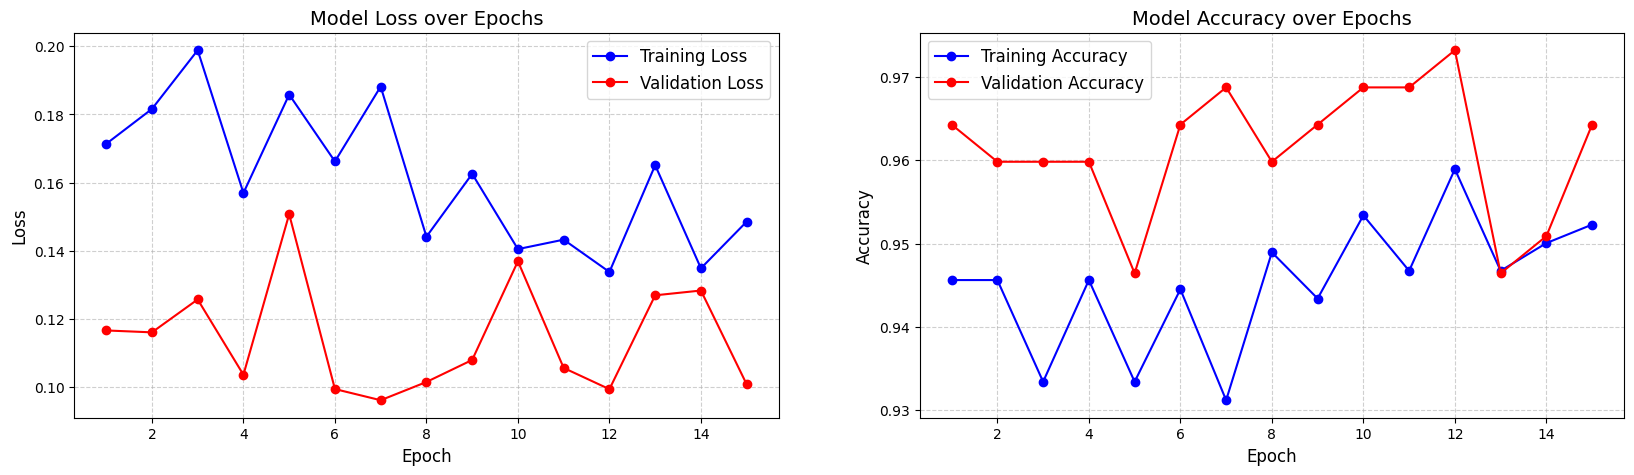

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
# loss
plt.subplot(1, 2, 1)
plt.plot(num_epochs, training_results['train_loss'], label='Training Loss', marker='o', color='blue')
plt.plot(num_epochs, training_results['val_loss'], label='Validation Loss', marker='o', color='red')
plt.title('Model Loss over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# accuracy
plt.subplot(1,2, 2)
plt.plot(num_epochs, training_results['train_acc'], label='Training Accuracy', marker='o', color='blue')
plt.plot(num_epochs, training_results['val_acc'], label='Validation Accuracy', marker='o', color='red')
plt.title('Model Accuracy over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

The reason why in validation phase the loss and accuracy are better than training phase is due to the process of randomly distorting the original image during training, where as in validation phase we only take the 224x224 center crop to feed to the model.
